In [398]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from iminuit import Minuit                             # The actual fitting tool, better than scipy's
import sys                                             # Module to see files and folders in directories
from scipy import stats
from iminuit import cost
from scipy.interpolate import PchipInterpolator, CubicSpline

from glacier_data import load_glacier_dataset, get_record


In [326]:
# props: one row per glacier, indexed by ID
# records: long format (ID, name, year, dL_m, source), one row per data point
props, records = load_glacier_dataset()

# Attach metadata to every data point, e.g. to filter by region or scale by L_1950
data = records.join(props.drop(columns='name'), on='ID')


In [327]:
def getIdFromName(name):
    return data[data['name'] == name]['ID'].iloc[0]

dat =data['region']
AletschId = getIdFromName('Gr Aletsch')
# AX010Id = getIdFromName("Brikdalsbreen")

In [328]:
c1 = 0.00204
c2 = 19

In [329]:
#Check data for nans
print("Checking data for NaNs...")
print(f"Number of NaNs in precip_m_per_a: {data['precip_m_per_a'].isnull().sum()}")
print(f"Number of NaNs in slope: {data['slope'].isnull().sum()}")
print(f"Number of NaNs in L1950_km: {data['L1950_km'].isnull().sum()}")
print(f"Number of NaNs in dL_m: {data['dL_m'].isnull().sum()}")
print(f"Number of NaNs in year: {data['year'].isnull().sum()}")
# remove data with nans
data = data.dropna(axis=0)

Checking data for NaNs...
Number of NaNs in precip_m_per_a: 14
Number of NaNs in slope: 22
Number of NaNs in L1950_km: 0
Number of NaNs in dL_m: 0
Number of NaNs in year: 0


In [330]:
def CalculateClimateProperties(GlacierFrame: pd.DataFrame, c1 = c1, c2 = c2):
    '''
    Calculate glacier sensitivity and response time
    :param Precip: Precipitation
    :param s: Avg slope of glacier
    :param c1: constant
    :param L: glacier length
    :return: Climate properties
    '''
    Precip = GlacierFrame['precip_m_per_a'].values[0]
    s = GlacierFrame['slope'].values[0]
    if s is None or Precip is None:
        print("Invalid data found in glacier")
        return None, None
    L = GlacierFrame['L1950_km'].values[0]*1e3
    beta = 0.0006*np.sqrt(Precip)
    gamma = c1*s/np.sqrt(Precip)
    tau =  c2*1/(beta*s*np.sqrt(1+20*s)*np.sqrt(L))
    return gamma, tau

In [331]:
#get list of valid glacier IDs

ids = data["ID"].unique()
GlacierSensProps = []

for calculation_id, glacier_id in enumerate(ids):
    glacier = data[data["ID"] == glacier_id]
    gamma, tau = CalculateClimateProperties(glacier)

    if tau < 0:
        print(f"Invalid glacier ID {glacier_id} in calculation {calculation_id}")
        continue

    GlacierSensProps.append({
        "calculation_id": calculation_id,
        "glacier_id": glacier_id,
        "gamma": gamma,
        "tau": tau,
    })


Invalid glacier ID 489 in calculation 127


In [332]:
gammas = [gi["gamma"] for gi in GlacierSensProps]
tau = [ti["tau"] for ti in GlacierSensProps]
GlacierSensProps = pd.DataFrame(GlacierSensProps)

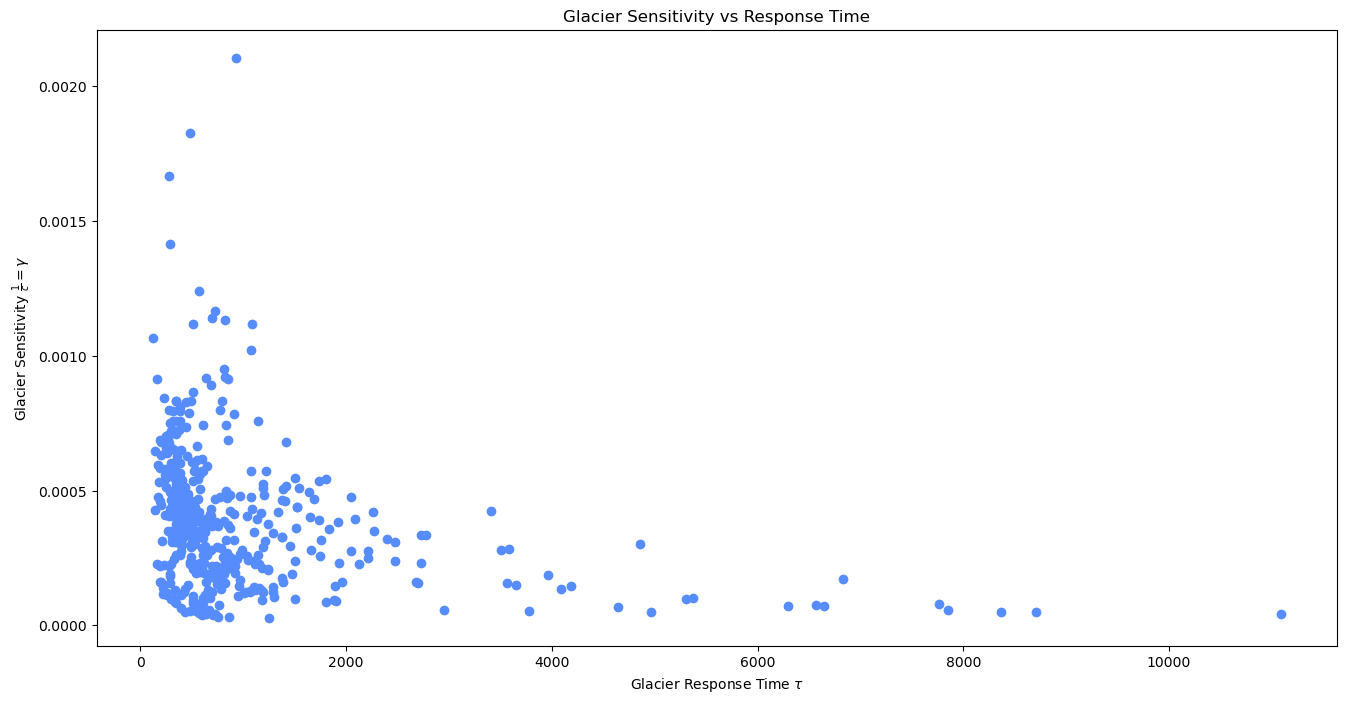

In [333]:
plt.figure(figsize=(16,8))
plt.scatter(tau, gammas)
plt.ylabel(r'Glacier Sensitivity $\frac{1}{c}=\gamma$')
plt.xlabel(r'Glacier Response Time $\tau$')
plt.title('Glacier Sensitivity vs Response Time')
plt.show()



In [415]:
def CalculateClimatePropertiesDL(GlacierFrame: pd.DataFrame, Length: np.ndarray, c1 = c1, c2 = c2, MinLength = 0.0):
    '''
    Regn tau og gamma
    :param GlacierFrame: Data for a single glacier
    :param Length: Glacier length [m] at each time step
    :param c1, c2: constants
    :param MinLength: Lengths at or below this value [m] are treated as invalid
    :return: gamma (scalar), tau (array, NaN where the length is invalid). (None, None) if the glacier can't be used
    '''
    Precip = GlacierFrame['precip_m_per_a'].values[0]
    s = GlacierFrame['slope'].values[0]
    L = GlacierFrame['L1950_km'].values[0]*1e3

    if not (np.isfinite(Precip) and np.isfinite(s) and Precip > 0 and s > 0):
        return None, None

    beta = 0.006*np.sqrt(Precip)
    gamma = c1*s/np.sqrt(Precip)

    tau = c2/(beta*s*np.sqrt(1+20*s)*np.sqrt(L))
    return gamma, tau

def PrepData(id: float, const1 = c1, const2 = c2):
    '''
    :param id: Id af gletsjer som skal inverteres
    :return: gamma, tau, SmoothTime, InterpLength. gamma is None if the glacier can't be used
    '''
    Glacier = data[data["ID"] == id]
    Time = Glacier['year']
    SmoothTime = np.arange(Time.min(), Time.max()+1, 1)
    ZeroIndex = np.argwhere(SmoothTime == 1950)
    if len(ZeroIndex) == 0:
        return None, None, SmoothTime, None
    # Pchip = PchipInterpolator(Time, Glacier['dL_m'])
    # SmoothDL = Pchip(SmoothTime)
    Cubic = CubicSpline(Time, Glacier['dL_m'])
    SmoothDL = Cubic(SmoothTime)
    SmoothDL = SmoothDL - SmoothDL[ZeroIndex][0]
    InterpLength = Glacier['L1950_km'].values[0]*1e3 + SmoothDL

    gamma, tau = CalculateClimatePropertiesDL(Glacier, InterpLength, const1, const2)
    if gamma is None:
        return None, None, SmoothTime, None

    return gamma, tau, SmoothTime, SmoothDL


In [416]:
def InvertLength(L : any, Time: any, c: float, tau: float ):
    '''
    Inverter for Temperatur
    :param L: Glacier Length with respect to reference state
    :param c: Glacier Sensitivity
    :param tau: Glacier Response Time
    :return: Temperature pertubation with respect to reference state
    '''
    dLDt = np.gradient(L, Time)
    T = -1/c*(L+tau*dLDt)
    return T


In [417]:
def RunModel(id: float, const1 = c1, const2 = c2):
    '''
    Kør én bestemt gletsjer
    :param id: Id of the glacier
    :param const1, const 2: Tuning parameters
    :return: Invertion to temperature (None if the glacier can't be used), SmoothTime
    '''
    gamma, tau, SmoothTime, InterpLength = PrepData(id, const1, const2)
    if gamma is None:
        return None, SmoothTime
    return InvertLength(L = InterpLength, Time = SmoothTime, c= 1/gamma, tau = tau), SmoothTime

# Temp, ModelTime = RunModel(29, 0.001, 0.2)

In [418]:
def RunWorldModel(C1, c2, region=None):
    """
   Kør hele møjet i en regione eller hvis ingen region er angivet så for alle gletsjere
    Returns
    -------
    years : np.ndarray
        Years in the reconstruction.
    mean_anomalies : np.ndarray
        Annual mean glacier temperature anomalies.
    """

    dataModel = data.copy()

    if region is not None:
        dataModel = dataModel[dataModel["region"] == region]

    ids = dataModel["ID"].unique()

    anomalies_by_year = {}

    for glacier_id in ids:
        temperatures, glacier_years = RunModel(glacier_id, const1=C1,const2=c2)


        temperatures = np.asarray(temperatures, dtype=float)
        glacier_years = np.asarray(glacier_years)

        baseline_mask = ((glacier_years >= 1945) & (glacier_years <= 1965))

        glacier_baseline = np.mean(temperatures[baseline_mask])
        glacier_anomalies = temperatures - glacier_baseline


        for year, anomaly in zip(glacier_years, glacier_anomalies):
            if np.isfinite(anomaly):
                anomalies_by_year.setdefault(year, []).append(anomaly)


    years = np.array(sorted(anomalies_by_year))
    mean_anomalies = np.array([ np.mean(anomalies_by_year[year]) for year in years ])

    # Hvis vi vil
    # reference_mask = (
    #     (years >= 1961)
    #     & (years <= 1990)
    #     & np.isfinite(mean_anomalies)
    # )

    # if not np.any(reference_mask):
    #     raise ValueError(
    #         "Ingen reference maske"
    #     )
    #
    # reference_mean = np.mean(mean_anomalies[reference_mask])
    # mean_anomalies = mean_anomalies - reference_mean

    return years, mean_anomalies


In [419]:
ModelTime, Temparray = RunWorldModel(
    0.00204,
    19,
    region= 9
)
# lidt debugging
print("First years:", ModelTime[:10])
print("Last years:", ModelTime[-10:])
print("Number of years:", len(ModelTime))
print("Year differences:", np.unique(np.diff(ModelTime)))
print("Duplicate years:", len(ModelTime) - len(np.unique(ModelTime)))
print("Continuous:", np.array_equal(
    ModelTime,
    np.arange(ModelTime.min(), ModelTime.max() + 1),
))

First years: [1535 1536 1537 1538 1539 1540 1541 1542 1543 1544]
Last years: [2002 2003 2004 2005 2006 2007 2008 2009 2010 2011]
Number of years: 477
Year differences: [1]
Duplicate years: 0
Continuous: True


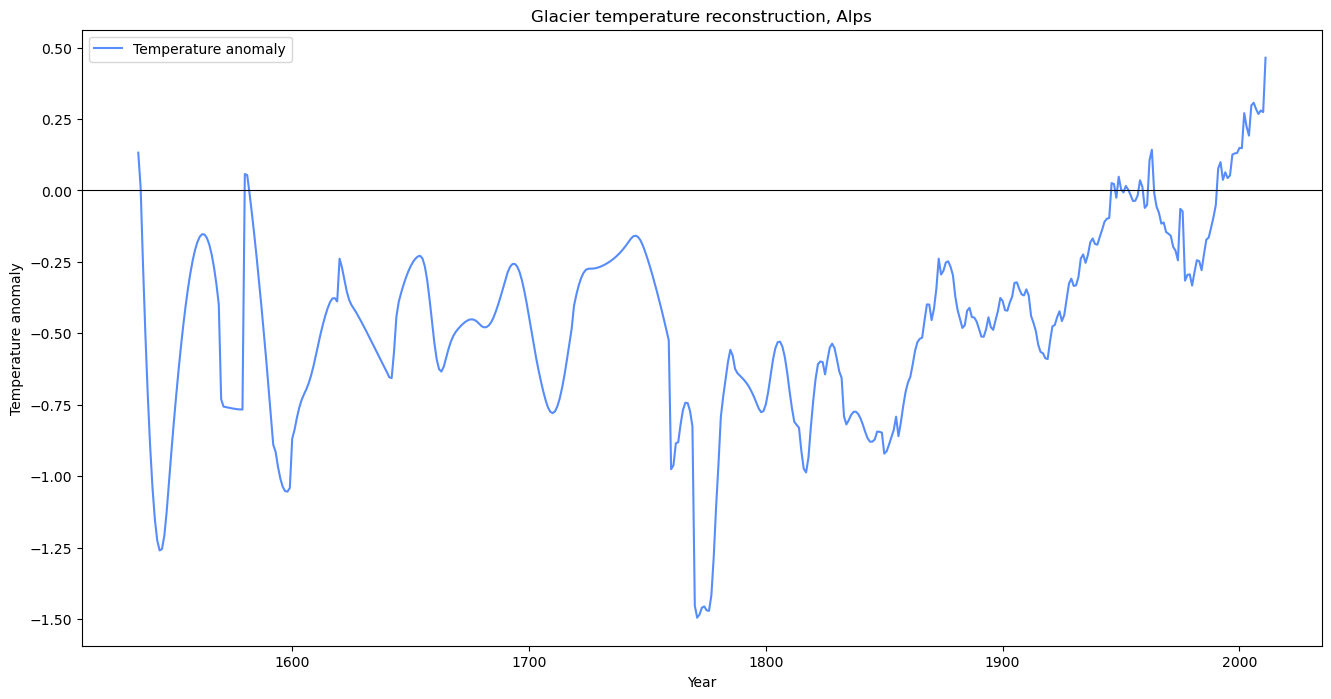

In [420]:
plt.figure(figsize=(16, 8))
plt.plot(ModelTime, Temparray, label="Temperature anomaly")
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Year")
plt.ylabel("Temperature anomaly")
plt.title("Glacier temperature reconstruction, Alps")
plt.legend()
plt.show()

In [445]:
c1, c2 = 2e-2, 3
#AletschGlacier
AletschTemp,AletschTime  = RunModel(66, c1, c2)
#Birkdal
BirkdalTemp,BirkdalTime = RunModel(26, c1, c2)
#Nigard
NigardTemp, NigardTime = RunModel(119, c1, c2)

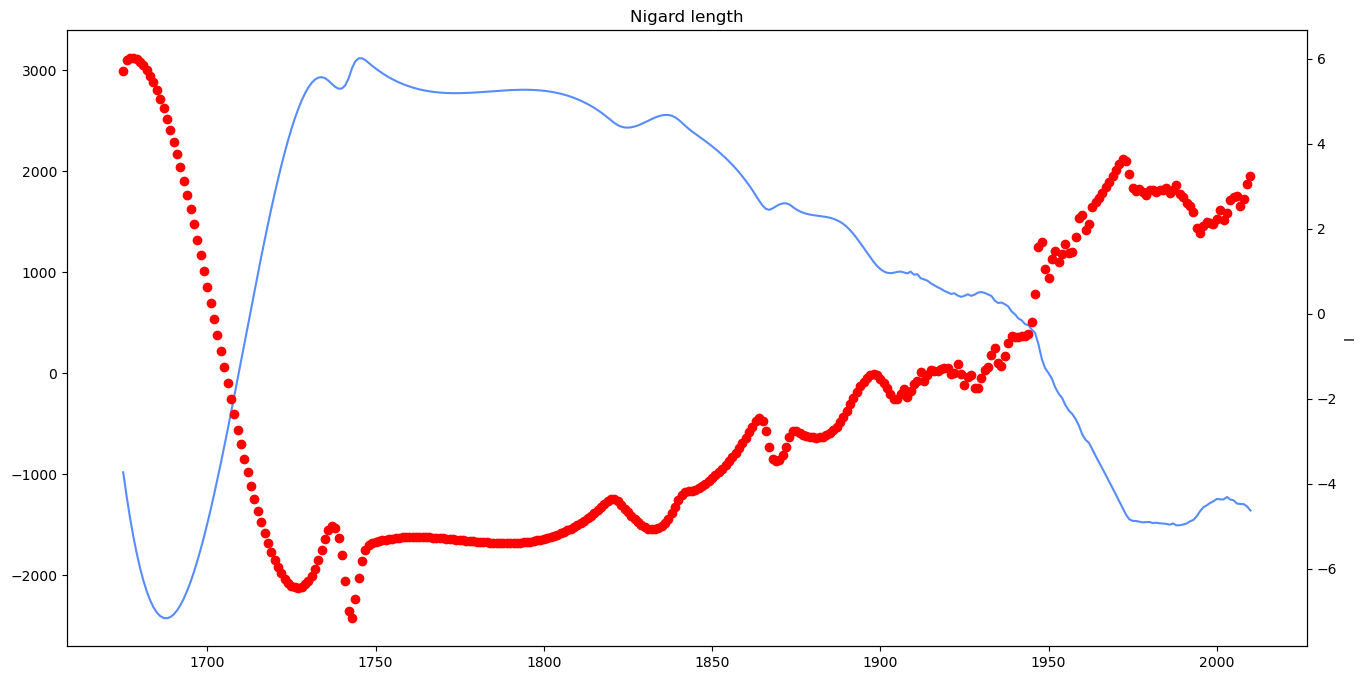

In [450]:
gamma, tau, SmoothTime, InterpLength = PrepData(119, 0.00204, 10)
plt.figure(figsize=(16, 8))
plt.plot(SmoothTime, InterpLength)
# plt.plot(SmoothTime, np.gradient(InterpLength)*3)
plt.twinx()
plt.plot(NigardTime, NigardTemp, 'ro')
plt.xlabel("Year")
plt.ylabel("I")
plt.title("Nigard length")
plt.show()

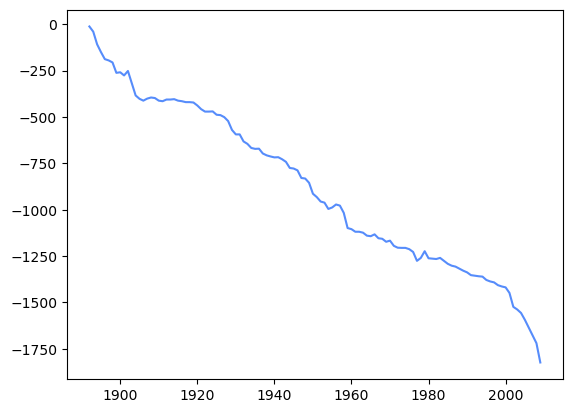

In [434]:
Birkdalsbreen = data[data["ID"] == 172]
rawLength = Birkdalsbreen['L1950_km']*1e-3 + Birkdalsbreen['dL_m']
rawTime = Birkdalsbreen['year']
plt.plot(rawTime, rawLength)

In [435]:
Rearth = 6368
2*np.pi *Rearth/360

111.14256676699891

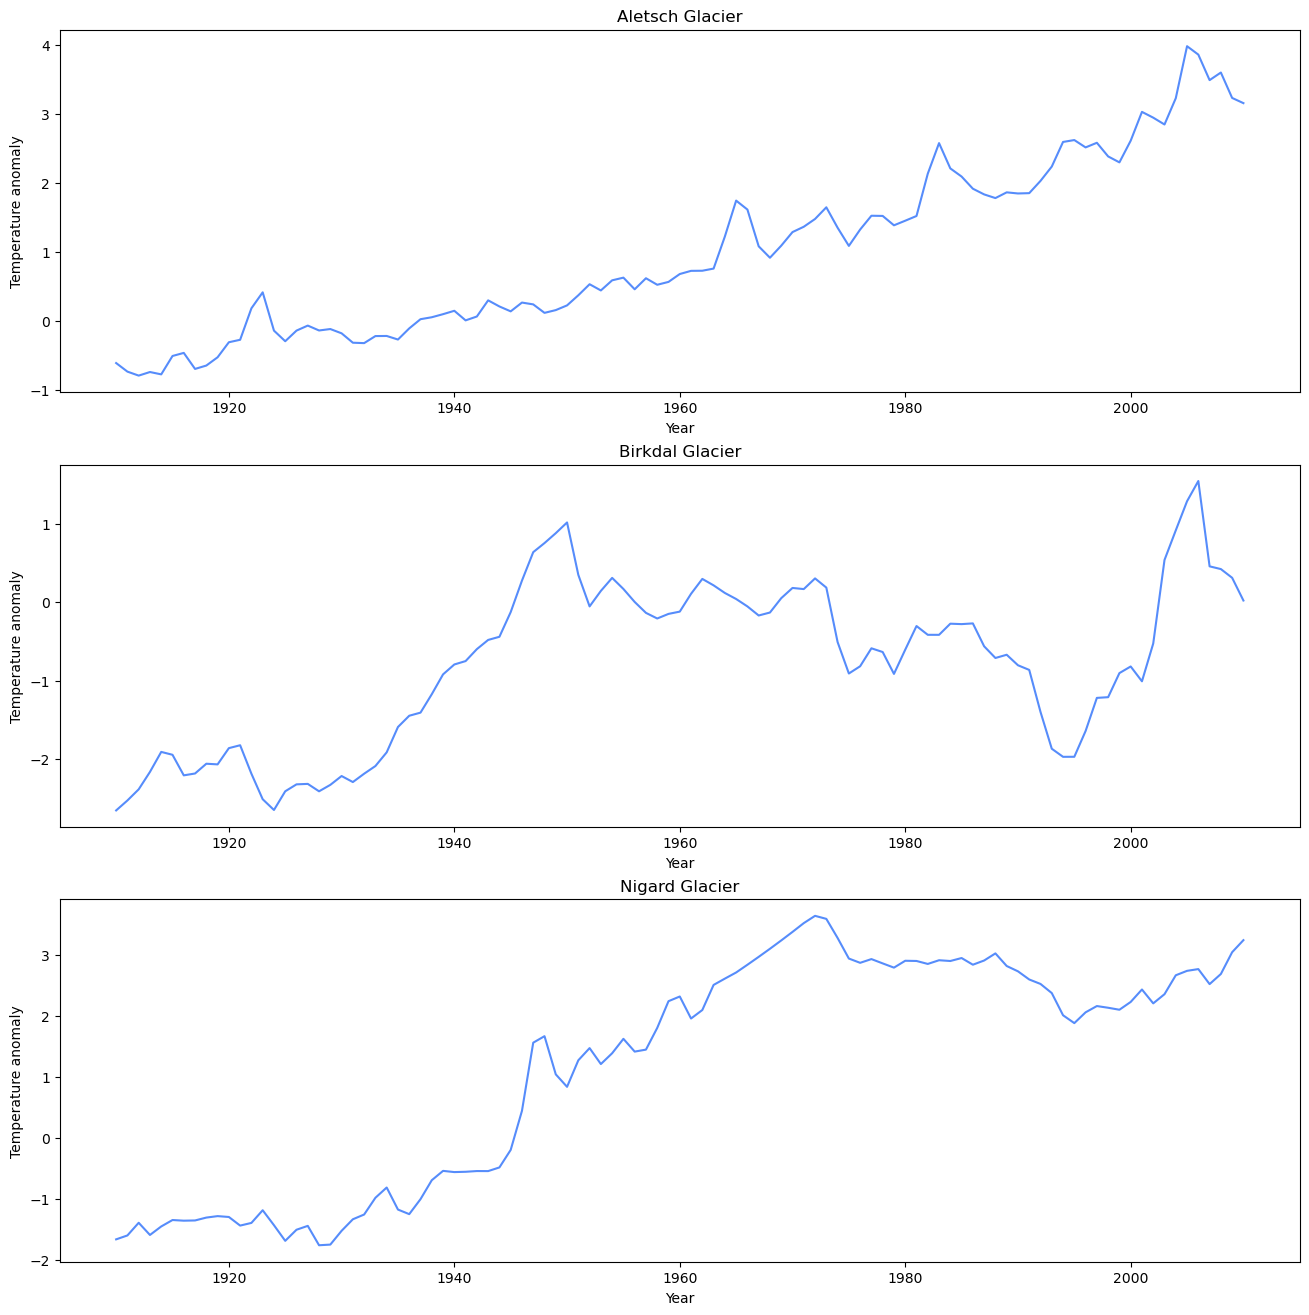

In [446]:
#plot the three glacier inverisons
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(16, 16))
timemaskA = AletschTime >= 1910
ax[0].plot(AletschTime[timemaskA], AletschTemp[timemaskA])
ax[0].set_title("Aletsch Glacier")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Temperature anomaly")
timemaskB = BirkdalTime >=1910
ax[1].plot(BirkdalTime[timemaskB], BirkdalTemp[timemaskB])
ax[1].set_title("Birkdal Glacier")
ax[1].set_xlabel("Year")
ax[1].set_ylabel("Temperature anomaly")
timemaskC = NigardTime >=1910
ax[2].plot(NigardTime[timemaskC], NigardTemp[timemaskC])
ax[2].set_title("Nigard Glacier")
ax[2].set_xlabel("Year")
ax[2].set_ylabel("Temperature anomaly")

plt.show()


In [437]:
# gamma, tau, SmoothTime, InterpLength = PrepData(AletschId, 0.00204, 40)


In [438]:
temperature_data = np.genfromtxt("data.csv",delimiter=",",skip_header=2)
TrueTemps = temperature_data[:, 1]
TrueTime = temperature_data[:, 0]


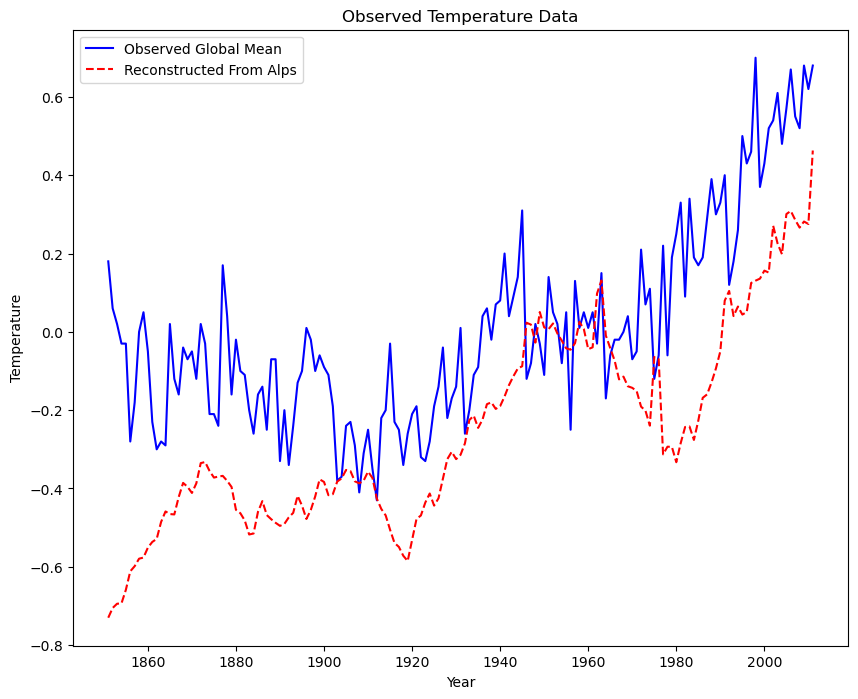

In [364]:
# ModelTime, Temparray = RunWorldModel(0.001, 1.9)
ModelCalibrationIndex = np.where(ModelTime == 1851)[0][0]
ModelTime = ModelTime[ModelCalibrationIndex:]
Temparray = Temparray[ModelCalibrationIndex:]
TrueTempsSmooth = np.interp(ModelTime, TrueTime, TrueTemps)

plt.figure(figsize=(10,8))
plt.plot(ModelTime, TrueTempsSmooth, 'b-', label='Observed Global Mean')
plt.plot(ModelTime, Temparray, 'r--', label='Reconstructed From Alps')
plt.xlabel('Year')
plt.ylabel('Temperature')
plt.title('Observed Temperature Data')
plt.legend()
plt.show()

In [344]:
modelStartindexfor1850 = np.where(ModelTime== 1851)[0][0]
TruncatedModelTime = ModelTime[modelStartindexfor1850:]
TruncatedModelTemps = Temparray[modelStartindexfor1850:]
# TruncatedModelStd = TempStd[modelStartindexfor1850:]
TruncatedRealTemp = temperature_data[1:-16][:, 1]

In [345]:
len(ModelTime)

477

In [348]:
# def FitWorldModel(year, const1, const2):
#     model_year, model_temp = RunWorldModel(const1, const2)
#     model_year = model_year[ModelCalibrationIndex:]
#     model_temp = model_temp[ModelCalibrationIndex:]
#     return model_temp
#
# cfit = cost.LeastSquares(
#     ModelTime,
#     TrueTempsSmooth,
#     0.1,
#     FitWorldModel,
# )
#
# mfit = Minuit(cfit, const1=c1, const2=c2)
# mfit.migrad()

In [347]:
# params = mfit.values[:]
# chi2 = mfit.fval
# ndof = len(ModelTime) - mfit.nfit
# prob = stats.chi2.sf(chi2, ndof)
#
# FitTime = ModelTime
# FitTemp = FitWorldModel(ModelTime, *params)
#
# figLin, axLin = plt.subplots(figsize=(16, 8))
#
# data_plot = axLin.errorbar(
#     ModelTime,
#     TrueTempsSmooth,
#     yerr=0.1,  # sigma used in cost.LeastSquares
#     fmt="ro",
#     ecolor="k",
#     elinewidth=1,
#     capsize=2,
#     capthick=1,
#     label="Data",
# )
#
# fit_plot, = axLin.plot(
#     FitTime,
#     FitTemp,
#     "-r",
#     linewidth=2,
#     label="Fit",
# )
#
# axLin.set_xlabel("Year", fontsize=18)
# axLin.set_ylabel("Temperature", fontsize=18)
# axLin.set_title("Temperature Reconstruction", fontsize=20)
# axLin.tick_params(axis="both", labelsize=14)
#
# first_legend = axLin.legend(fontsize=18, loc="upper left")
#
# fit_info = (
#     f"$\\chi^2$ / $N_\\mathrm{{dof}}$ = {chi2:.1f} / {ndof}\n"
#     f"Prob($\\chi^2$, $N_\\mathrm{{dof}}$) = {prob:.3f}\n"
# )
#
# for parameter, value, error in zip(
#     mfit.parameters,
#     mfit.values[:],
#     mfit.errors[:],
# ):
#     n_decimals = max(
#         0,
#         int(-np.floor(np.log10(error)) + 1),
#     )
#     fit_info += (
#         f"{parameter} = "
#         f"${value:.{n_decimals}f} \\pm {error:.{n_decimals}f}$\n"
#     )
#
# fit_results, = axLin.plot(
#     [],
#     [],
#     color="none",
#     label=fit_info,
# )
#
# second_legend = axLin.legend(
#     title="Result of fit:",
#     handles=[fit_results],
#     fontsize=18,
#     title_fontsize=20,
#     alignment="left",
#     handlelength=0,
#     handletextpad=0,
#     loc="lower right",
# )
#
# axLin.add_artist(first_legend)
# plt.tight_layout()
# plt.show()